In [2]:
import dataclasses
import glob
import itertools
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns

from lib.kernel_estimates import kernel_regression, make_gaussian_kernel
from lib.plots import faint_color, reverse_legend, set_axis, attach_colorbar
from lib.stats import fit_power_law

In [3]:
def faint_cmap(cmap, level: float = 0.5, n: int = 100):
    colors = cmap(np.linspace(0, 1, num=n))
    return plt.matplotlib.colors.LinearSegmentedColormap.from_list(
        "",
        [faint_color(c, level) for c in colors]
    )

In [4]:
task_id = "15-loop_capture_sweep"
config_count = 100

In [5]:
@dataclasses.dataclass
class TaskData:
    frame_duration: float
    msd: np.ndarray             # (configs, replicates, lag)
    loop_coverage: np.ndarray   # (configs, replicates)
    rg: np.ndarray              # (configs, replicates)
    params: list[dict]


phase_key = "production"
msd_lag_cutoff = 11


def load_task_data(task_id: str) -> TaskData:
    msd_ensemble = []
    cov_ensemble = []
    rg_ensemble = []
    params_ensemble = []

    for config_id in range(config_count):
        with h5py.File(f"{task_id}/_outputs/metrics-{config_id}.h5", "r") as store:
            config_source = json.loads(store["config_source"][()])
            config_used = json.loads(store["config_used"][()])
            meta = config_source["@meta"]

            site_msds = store["site_msds"][:, :msd_lag_cutoff, :]   # (replicates, lag, sites)
            if "loop_coverages_nonred" in store:
                loop_covs = store["loop_coverages_nonred"][:, :]    # (replicates, time)
            else:
                loop_covs = store["loop_coverages"][:, :]           # (replicates, time)
            chain_rgs = store["chain_rgs"][:, :]                    # (replicates, time)

            msd_ensemble.append(site_msds)
            cov_ensemble.append(loop_covs)
            rg_ensemble.append(chain_rgs)
            params_ensemble.append({**meta["config_params"], **meta["config_info"]})

    # Fill missing replica results with NaNs
    def nanify_missing_replica(results):
        replica_count = max(map(len, results))
        return [
            np.concatenate([
                x,
                np.full((replica_count - x.shape[0], *x.shape[1:]), np.nan)
            ])
            for x in results
        ]

    msd_ensemble = nanify_missing_replica(msd_ensemble)
    cov_ensemble = nanify_missing_replica(cov_ensemble)
    rg_ensemble = nanify_missing_replica(rg_ensemble)

    # All configs in the same task share the same sampling settings.
    # Take the last one.
    sampling_config = config_used["sampling"]
    phase_configs = {phase["name"]: phase for phase in sampling_config["phases"]}
    phase_config = {**sampling_config, **phase_configs[phase_key]}
    frame_duration = phase_config["timestep"] * phase_config["sampling_interval"]

    msd_ensemble = np.array(msd_ensemble)   # (configs, replicates, lag, sites)
    cov_ensemble = np.array(cov_ensemble)   # (configs, replicates, time)
    rg_ensemble = np.array(rg_ensemble)     # (configs, replicates, time)

    return TaskData(
        frame_duration=frame_duration,
        msd=msd_ensemble.mean(axis=3),
        loop_coverage=cov_ensemble.mean(axis=2),
        rg=rg_ensemble.mean(axis=2),
        params=params_ensemble,
    )


task_data = load_task_data(task_id)

In [6]:
@dataclasses.dataclass
class TaskEstimates:
    msd_alpha: np.ndarray       # (configs, replicates)
    msd_prefactor: np.ndarray   # (configs, replicates)


def compute_task_estimates(data: TaskData) -> TaskEstimates:
    # Normalize lag time to the last value. This way the prefactor for the
    # power-law has the well-defined unit. The functional form is thus
    #   M(Δt) = prefactor * (Δt / τ0)^α
    # where τ0 is the largest lag time.
    x = np.linspace(0, 1, num=data.msd.shape[-1])

    msd_dataset = np.reshape(data.msd, (-1, data.msd.shape[-1]))

    msd_alpha = []
    msd_prefactor = []
    for i in range(msd_dataset.shape[0]):
        y = msd_dataset[i]
        if all(np.isnan(y)):
            alpha, prefactor = np.nan, np.nan
        else:
            alpha, prefactor = fit_power_law(x, y)
        msd_alpha.append(alpha)
        msd_prefactor.append(prefactor)

    return TaskEstimates(
        msd_alpha=np.reshape(msd_alpha, data.msd.shape[:-1]),
        msd_prefactor=np.reshape(msd_prefactor, data.msd.shape[:-1]),
    )


task_estimates = compute_task_estimates(task_data)

In [7]:
gene_size = np.array([p["realized_gene_size"] for p in task_data.params])
gene_frac = np.array([p["realized_gene_size"] for p in task_data.params])
traffic_rate = np.array([p["LC_traffic_rate"] for p in task_data.params])

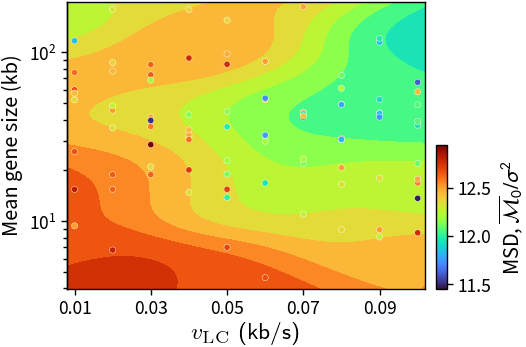

In [8]:
fig, ax = plt.subplots(figsize=(2.2, 1.8))

# Scatter
x = traffic_rate
y = np.log10(gene_size)
z = task_estimates.msd_prefactor.mean(axis=1)

mask = np.isfinite(z)
x = x[mask]
y = y[mask]
z = z[mask]
sm = ax.scatter(x, y, c=z, s=5, lw=0.15, ec="w", cmap="turbo", zorder=3)

# Contour plot
x_points = np.linspace(0.008, 0.102, num=100)
y_points = np.linspace(0.6, 2.3, num=100)
mesh_x, mesh_y = np.meshgrid(x_points, y_points)

mesh_z = kernel_regression(
    np.transpose([mesh_x.ravel(), mesh_y.ravel()]),
    np.transpose([x, y]),
    z,
    kernel_fn=make_gaussian_kernel(2),
    scale=(1 / 0.015, 1 / 0.15),
)
mesh_z = mesh_z.reshape(mesh_x.shape)

ax.contourf(
    mesh_x, mesh_y, mesh_z,
    #norm=sm.norm, cmap=faint_cmap(sm.cmap, level=0.5), levels=8, zorder=2,
    norm=sm.norm, cmap=sm.cmap, levels=8, zorder=2,
)

#
set_axis(ax, ticks="bottom", spines="all")

ax.set_xticks([0.01, 0.03, 0.05, 0.07, 0.09])

pow10 = lambda x: 10 ** x
log10 = np.log10
y_ax = ax.secondary_yaxis("left", functions=(pow10, log10))
y_ax.set_zorder(10)
y_ax.set_yscale("log")

cbar = attach_colorbar(ax, sm)
cbar.set_label(r"MSD, $ \overline{\mathcal{M}}_0 / \sigma^2 $")
cbar.solids.set_rasterized(False) 

ax.set_xlabel(r"$ v_\mathrm{LC} $ (kb/s)", usetex=True)
y_ax.set_ylabel("Mean gene size (kb)")

fig.savefig(f"_figs/LCsweep-{task_id}-M0.svg")

pass

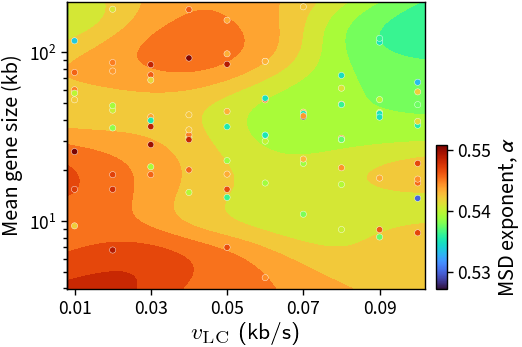

In [9]:
fig, ax = plt.subplots(figsize=(2.2, 1.8))

# Scatter
x = traffic_rate
y = np.log10(gene_size)
z = task_estimates.msd_alpha.mean(axis=1)

mask = np.isfinite(z)
x = x[mask]
y = y[mask]
z = z[mask]
sm = ax.scatter(x, y, c=z, s=5, lw=0.15, ec="w", cmap="turbo", zorder=3)

# Contour plot
x_points = np.linspace(0.008, 0.102, num=100)
y_points = np.linspace(0.6, 2.3, num=100)
mesh_x, mesh_y = np.meshgrid(x_points, y_points)

mesh_z = kernel_regression(
    np.transpose([mesh_x.ravel(), mesh_y.ravel()]),
    np.transpose([x, y]),
    z,
    kernel_fn=make_gaussian_kernel(2),
    scale=(1 / 0.015, 1 / 0.15),
)
mesh_z = mesh_z.reshape(mesh_x.shape)

ax.contourf(
    mesh_x, mesh_y, mesh_z,
    #norm=sm.norm, cmap=faint_cmap(sm.cmap, level=0.5), levels=8, zorder=2,
    norm=sm.norm, cmap=sm.cmap, levels=8, zorder=2,
)

#
set_axis(ax, ticks="bottom", spines="all")

ax.set_xticks([0.01, 0.03, 0.05, 0.07, 0.09])

pow10 = lambda x: 10 ** x
log10 = np.log10
y_ax = ax.secondary_yaxis("left", functions=(pow10, log10))
y_ax.set_zorder(10)
y_ax.set_yscale("log")

cbar = attach_colorbar(ax, sm)
cbar.set_label(r"MSD exponent, $ \alpha $")
cbar.solids.set_rasterized(False)

ax.set_xlabel(r"$ v_\mathrm{LC} $ (kb/s)", usetex=True)
y_ax.set_ylabel("Mean gene size (kb)")

fig.savefig(f"_figs/LCsweep-{task_id}-alpha.svg")

pass